In [ ]:
!pip -q install xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [ ]:
expression = pd.read_csv("expression_filtered.csv", index_col=0)
clinical = pd.read_csv("clinical_matched.csv")

In [ ]:
print("Expression Shape:", expression.shape)
print("Clinical Shape:", clinical.shape)

expression.head()

Expression Shape: (17030, 744)
Clinical Shape: (744, 194)


,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AR-A0TV-01,TCGA-BH-A18J-01,TCGA-BH-A0W7-01,TCGA-BH-A0HA-01,...,TCGA-D8-A1X6-01,TCGA-BH-A0BL-01,TCGA-BH-A0DO-01,TCGA-A2-A04Q-01,TCGA-E9-A1NI-01,TCGA-AR-A24T-01,TCGA-AO-A0JA-01,TCGA-D8-A1XZ-01,TCGA-E2-A15F-01,TCGA-B6-A0X7-01
Gene,,,,,,,,,,,,,,,,,,,,,
ARHGEF10L,7.4346,9.3216,9.0198,9.6417,9.7665,10.0931,9.6694,9.2718,9.5610,9.8078,...,8.8809,9.5235,10.4995,10.0640,9.7984,8.6545,8.9976,8.5721,10.0334,10.5745
HIF3A,3.6607,2.7224,1.3414,0.5819,0.2738,3.6090,0.4330,2.1682,2.6648,1.9196,...,0.5947,6.2779,3.9977,2.2799,4.2270,0.4028,0.7707,1.5668,0.8836,4.0696
RNF10,11.9181,11.9665,13.1881,12.0036,11.8118,11.3820,11.9378,12.3127,11.9861,12.4059,...,12.1456,11.4204,11.8661,11.7065,12.5475,11.6361,12.0733,11.9794,12.0135,11.8663
RNF11,13.5273,11.4105,11.0911,11.2545,10.8554,10.7663,11.2889,11.2739,10.8410,11.4196,...,11.1187,11.0695,11.1226,10.7574,10.6631,11.1444,11.1703,10.8409,10.8370,10.7644
RNF13,10.8702,10.4406,10.4244,10.1480,10.4282,10.3366,10.6282,9.9904,10.0474,10.4422,...,10.1944,10.0744,10.3785,10.4053,10.6952,10.9800,10.3678,10.5156,10.5614,10.4864


In [ ]:
labels = np.where(
    (clinical["ER_Status_nature2012"] == "Negative") &
    (clinical["PR_Status_nature2012"] == "Negative") &
    (clinical["HER2_Final_Status_nature2012"] == "Negative"),
    1,
    0
)

labels = pd.Series(labels, index=clinical.index)

print("TNBC:", (labels == 1).sum())
print("Non-TNBC:", (labels == 0).sum())

TNBC: 123
Non-TNBC: 621


In [ ]:
X = expression.T

# Convert to float32 to reduce memory usage
X = X.astype(np.float32)

y = labels

print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (744, 17030)
Target: (744,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(595, 17030)
(149, 17030)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Random Forest Performance
----------------------------------------
Accuracy : 0.9194630872483222
Precision: 0.7407407407407407
Recall   : 0.8
F1 Score : 0.7692307692307693
ROC-AUC  : 0.8912903225806451

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       124
           1       0.74      0.80      0.77        25

    accuracy                           0.92       149
   macro avg       0.85      0.87      0.86       149
weighted avg       0.92      0.92      0.92       149



In [ ]:
et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)
et_prob = et.predict_proba(X_test)[:, 1]

print("ExtraTrees Performance")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, et_pred))
print("Precision:", precision_score(y_test, et_pred))
print("Recall   :", recall_score(y_test, et_pred))
print("F1 Score :", f1_score(y_test, et_pred))
print("ROC-AUC  :", roc_auc_score(y_test, et_prob))

print("\nClassification Report")
print(classification_report(y_test, et_pred))

ExtraTrees Performance
----------------------------------------
Accuracy : 0.912751677852349
Precision: 0.75
Recall   : 0.72
F1 Score : 0.7346938775510204
ROC-AUC  : 0.9066129032258065

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       124
           1       0.75      0.72      0.73        25

    accuracy                           0.91       149
   macro avg       0.85      0.84      0.84       149
weighted avg       0.91      0.91      0.91       149



In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Performance")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

XGBoost Performance
----------------------------------------
Accuracy : 0.912751677852349
Precision: 0.7307692307692307
Recall   : 0.76
F1 Score : 0.7450980392156863
ROC-AUC  : 0.893225806451613

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       124
           1       0.73      0.76      0.75        25

    accuracy                           0.91       149
   macro avg       0.84      0.85      0.85       149
weighted avg       0.91      0.91      0.91       149



In [ ]:
cat = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)
cat_prob = cat.predict_proba(X_test)[:, 1]

print("CatBoost Performance")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, cat_pred))
print("Precision:", precision_score(y_test, cat_pred))
print("Recall   :", recall_score(y_test, cat_pred))
print("F1 Score :", f1_score(y_test, cat_pred))
print("ROC-AUC  :", roc_auc_score(y_test, cat_prob))

print("\nClassification Report")
print(classification_report(y_test, cat_pred))

CatBoost Performance
----------------------------------------
Accuracy : 0.9060402684563759
Precision: 0.72
Recall   : 0.72
F1 Score : 0.72
ROC-AUC  : 0.8945161290322581

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       124
           1       0.72      0.72      0.72        25

    accuracy                           0.91       149
   macro avg       0.83      0.83      0.83       149
weighted avg       0.91      0.91      0.91       149



In [ ]:
import pandas as pd

performance = pd.DataFrame({
    "Model": [
        "Random Forest",
        "ExtraTrees",
        "XGBoost",
        "CatBoost"
    ],
    "Accuracy": [
        0.919463,
        0.912752,
        0.912752,
        0.906040
    ],
    "Precision": [
        0.740741,
        0.750000,
        0.730769,
        0.720000
    ],
    "Recall": [
        0.800000,
        0.720000,
        0.760000,
        0.720000
    ],
    "F1 Score": [
        0.769231,
        0.734694,
        0.745098,
        0.720000
    ],
    "ROC-AUC": [
        0.891290,
        0.906613,
        0.893226,
        0.894516
    ]
})

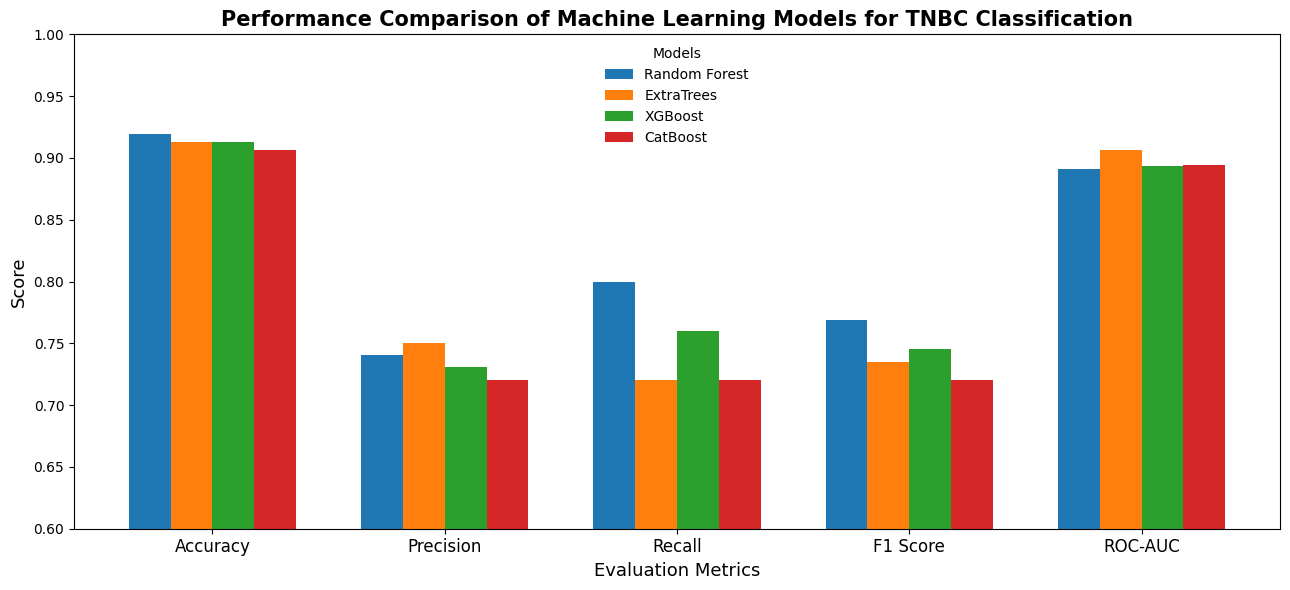

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = performance.columns[1:]

x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(13,6))

for i, model in enumerate(performance["Model"]):
    ax.bar(
        x + i * width,
        performance.loc[i, metrics],
        width=width,
        label=model
    )

ax.set_xticks(x + width * (len(performance["Model"]) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=12)

ax.set_ylim(0.60, 1.00)

ax.set_ylabel("Score", fontsize=13)
ax.set_xlabel("Evaluation Metrics", fontsize=13)

ax.set_title(
    "Performance Comparison of Machine Learning Models for TNBC Classification",
    fontsize=15,
    fontweight="bold"
)

ax.legend(title="Models", frameon=False)

plt.tight_layout()

plt.savefig(
    "Figure1_Model_Performance_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

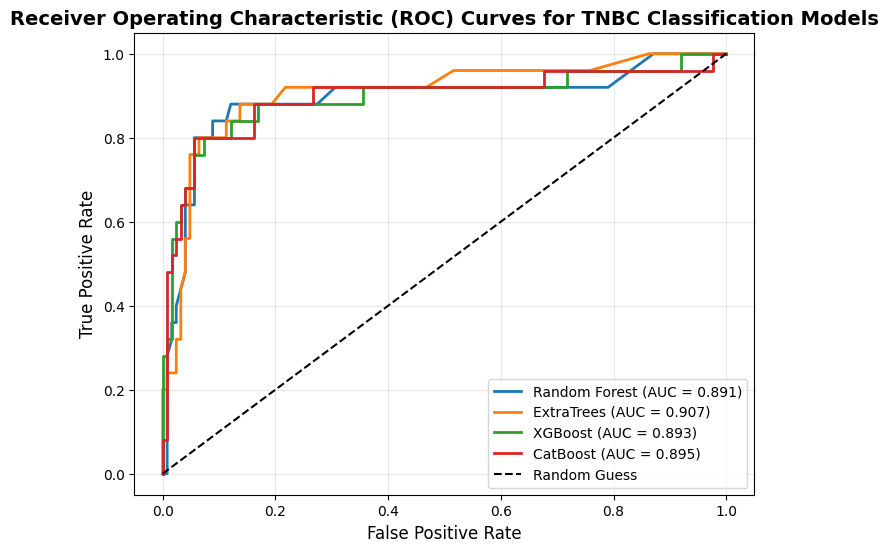

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

# ExtraTrees
fpr_et, tpr_et, _ = roc_curve(y_test, et_prob)
plt.plot(
    fpr_et,
    tpr_et,
    linewidth=2,
    label=f"ExtraTrees (AUC = {roc_auc_score(y_test, et_prob):.3f})"
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})"
)

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_prob)
plt.plot(
    fpr_cat,
    tpr_cat,
    linewidth=2,
    label=f"CatBoost (AUC = {roc_auc_score(y_test, cat_prob):.3f})"
)

# Random Guess
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Guess")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title(
    "Receiver Operating Characteristic (ROC) Curves for TNBC Classification Models",
    fontsize=14,
    fontweight="bold"
)

plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.savefig(
    "Figure2_ROC_Curves.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

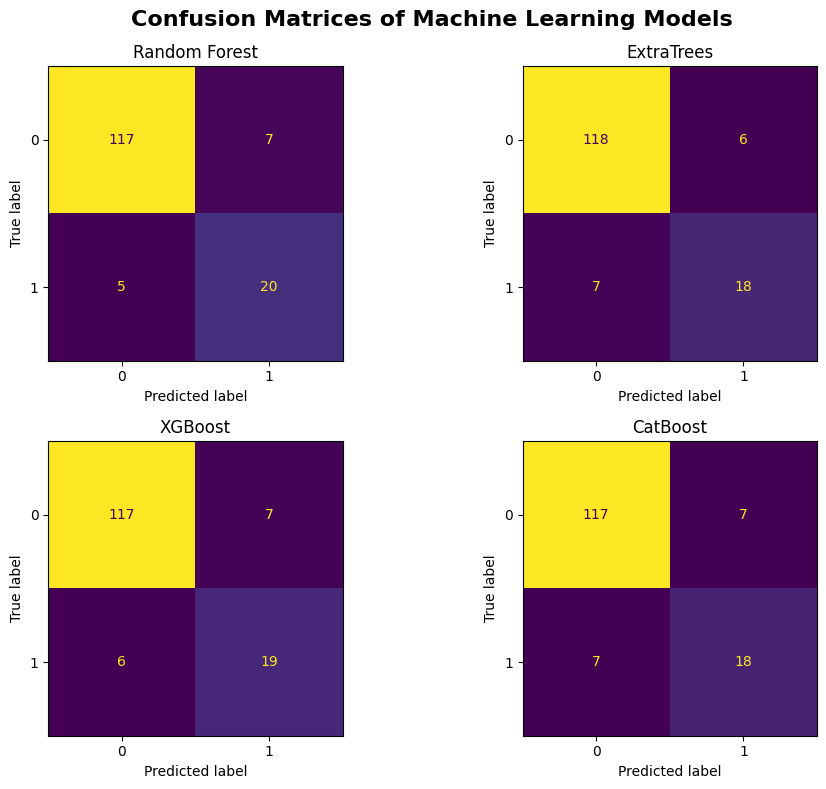

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    ax=axes[0,0],
    colorbar=False
)
axes[0,0].set_title("Random Forest")

# ExtraTrees
ConfusionMatrixDisplay.from_predictions(
    y_test, et_pred,
    ax=axes[0,1],
    colorbar=False
)
axes[0,1].set_title("ExtraTrees")

# XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred,
    ax=axes[1,0],
    colorbar=False
)
axes[1,0].set_title("XGBoost")

# CatBoost
ConfusionMatrixDisplay.from_predictions(
    y_test, cat_pred,
    ax=axes[1,1],
    colorbar=False
)
axes[1,1].set_title("CatBoost")

plt.suptitle(
    "Confusion Matrices of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure3_Confusion_Matrices.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

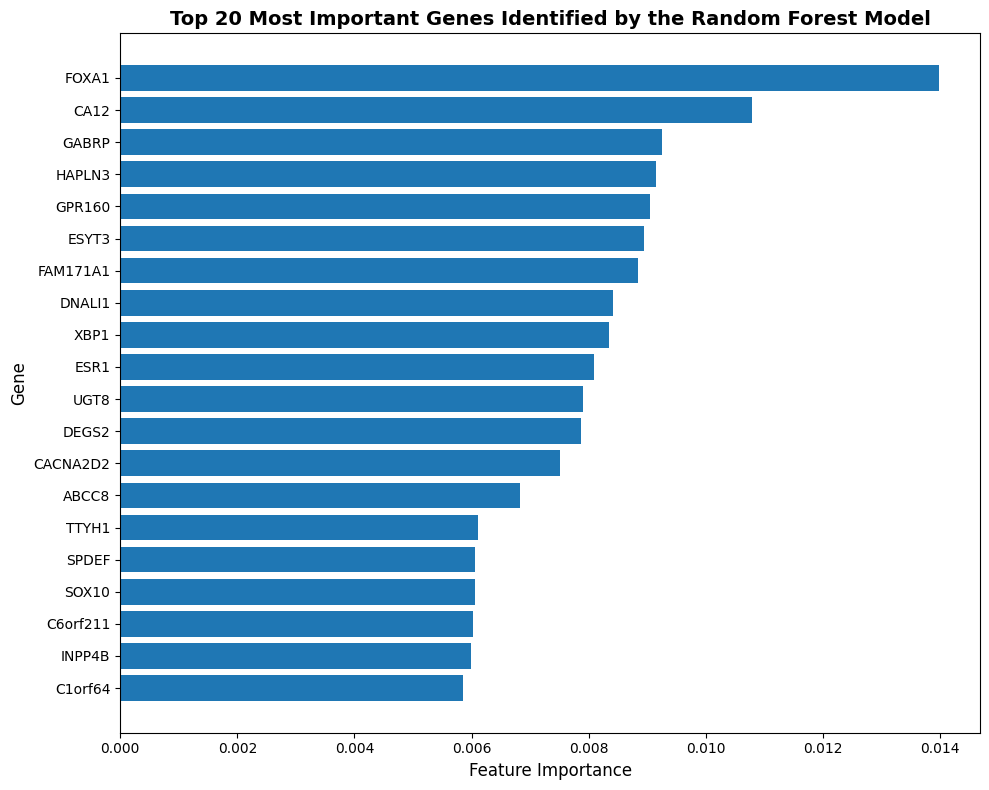

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a dataframe of feature importances
feature_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 20 genes
top20 = feature_importance.head(20)

# Plot
plt.figure(figsize=(10,8))

plt.barh(
    top20["Gene"][::-1],
    top20["Importance"][::-1]
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.title(
    "Top 20 Most Important Genes Identified by the Random Forest Model",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure4_RF_Top20_Genes.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
top20.to_csv("Top20_RF_Genes.csv", index=False)

top20

,Gene,Importance
12376,FOXA1,0.013978
4544,CA12,0.010793
3354,GABRP,0.009256
5841,HAPLN3,0.009149
8408,GPR160,0.009039
15147,ESYT3,0.008934
6119,FAM171A1,0.008847
8762,DNALI1,0.008404
8580,XBP1,0.008343
8285,ESR1,0.008091


In [ ]:
import pandas as pd

# Create dataframe of XGBoost feature importances
xgb_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": xgb.feature_importances_
})

# Sort by importance
xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

# Extract Top 20 genes
top20_xgb = xgb_importance.head(20)

# Display
top20_xgb

,Gene,Importance
12376,FOXA1,0.133130
613,TBC1D9,0.071194
3917,FOXC1,0.057268
8285,ESR1,0.025455
1399,B3GNT5,0.023254
6502,PPP1R14C,0.020894
11795,GATA3,0.019643
4544,CA12,0.013793
4303,BBS1,0.012642
9013,CD300LG,0.012450


In [ ]:
top20_xgb.to_csv("Top20_XGBoost_Genes.csv", index=False)

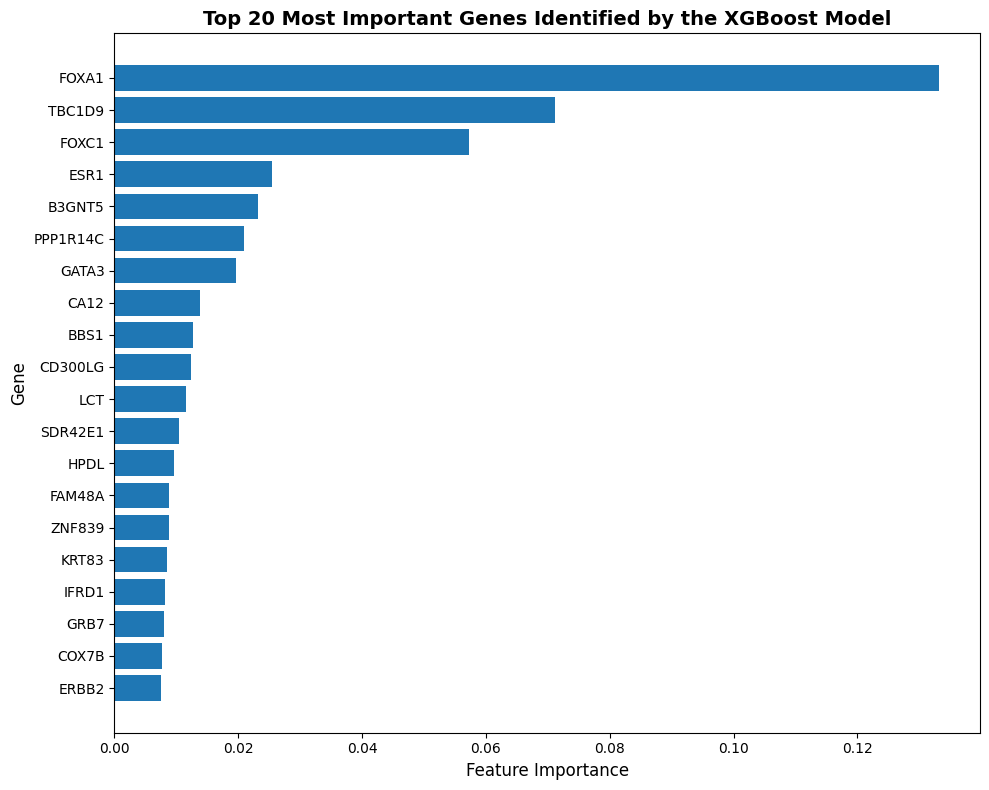

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    top20_xgb["Gene"][::-1],
    top20_xgb["Importance"][::-1]
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.title(
    "Top 20 Most Important Genes Identified by the XGBoost Model",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure5_XGB_Top20_Genes.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
et_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": et.feature_importances_
}).sort_values(by="Importance", ascending=False)

top20_et = et_importance.head(20)

top20_et.to_csv("Top20_ExtraTrees_Genes.csv", index=False)

top20_et

,Gene,Importance
3917,FOXC1,0.006724
7524,AR,0.005831
8762,DNALI1,0.005071
1399,B3GNT5,0.004996
12961,RASGEF1C,0.004932
16216,ZMYND10,0.004904
12801,DACH1,0.004551
11795,GATA3,0.004526
15358,VGLL1,0.004313
12910,LEMD1,0.004146


In [ ]:
cat_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": cat.feature_importances_
}).sort_values(by="Importance", ascending=False)

top20_cat = cat_importance.head(20)

top20_cat.to_csv("Top20_CatBoost_Genes.csv", index=False)

top20_cat

,Gene,Importance
3917,FOXC1,7.940204
10981,TMEM217,3.770937
8285,ESR1,2.984297
9692,PRR15,2.909260
613,TBC1D9,2.818373
1228,FSIP1,2.690301
10943,MICALL1,2.444102
14460,DZIP1,2.155360
2065,RABEP1,1.803066
4544,CA12,1.668571


In [ ]:
rf_genes = set(top20["Gene"])
et_genes = set(top20_et["Gene"])
xgb_genes = set(top20_xgb["Gene"])
cat_genes = set(top20_cat["Gene"])

# Genes present in all four models
common_genes = rf_genes & et_genes & xgb_genes & cat_genes

print(f"Common genes across all models: {len(common_genes)}")
print(sorted(common_genes))

Common genes across all models: 0
[]


In [ ]:
# Create a dataframe indicating whether each gene appears in each model

all_genes = sorted(rf_genes | et_genes | xgb_genes | cat_genes)

consensus = pd.DataFrame(index=all_genes)

consensus["Random Forest"] = [gene in rf_genes for gene in all_genes]
consensus["ExtraTrees"] = [gene in et_genes for gene in all_genes]
consensus["XGBoost"] = [gene in xgb_genes for gene in all_genes]
consensus["CatBoost"] = [gene in cat_genes for gene in all_genes]

# Count in how many models each gene appears
consensus["Models Supporting"] = consensus.sum(axis=1)

# Sort by support
consensus = consensus.sort_values(
    by="Models Supporting",
    ascending=False
)

consensus.head(30)

,Random Forest,ExtraTrees,XGBoost,CatBoost,Models Supporting
CA12,True,False,True,True,3
FOXC1,False,True,True,True,3
FOXA1,True,True,True,False,3
ESR1,True,False,True,True,3
DNALI1,True,True,False,False,2
B3GNT5,False,True,True,False,2
GATA3,False,True,True,False,2
HAPLN3,True,False,False,True,2
TBC1D9,False,False,True,True,2
UGT8,True,True,False,False,2


In [ ]:
consensus.to_csv("Consensus_Biomarkers.csv")

In [ ]:
# Select genes supported by at least 3 models
consensus_genes = consensus[
    consensus["Models Supporting"] >= 3
].index.tolist()

print(f"Number of consensus genes: {len(consensus_genes)}")
print(consensus_genes)

Number of consensus genes: 4
['CA12', 'FOXC1', 'FOXA1', 'ESR1']


In [ ]:
print(clinical.columns.tolist())

['Unnamed: 0', 'AJCC_Stage_nature2012', 'Age_at_Initial_Pathologic_Diagnosis_nature2012', 'CN_Clusters_nature2012', 'Converted_Stage_nature2012', 'Days_to_Date_of_Last_Contact_nature2012', 'Days_to_date_of_Death_nature2012', 'ER_Status_nature2012', 'Gender_nature2012', 'HER2_Final_Status_nature2012', 'Integrated_Clusters_no_exp__nature2012', 'Integrated_Clusters_unsup_exp__nature2012', 'Integrated_Clusters_with_PAM50__nature2012', 'Metastasis_Coded_nature2012', 'Metastasis_nature2012', 'Node_Coded_nature2012', 'Node_nature2012', 'OS_Time_nature2012', 'OS_event_nature2012', 'PAM50Call_RNAseq', 'PAM50_mRNA_nature2012', 'PR_Status_nature2012', 'RPPA_Clusters_nature2012', 'SigClust_Intrinsic_mRNA_nature2012', 'SigClust_Unsupervised_mRNA_nature2012', 'Survival_Data_Form_nature2012', 'Tumor_T1_Coded_nature2012', 'Tumor_nature2012', 'Vital_Status_nature2012', '_INTEGRATION', '_PANCAN_CNA_PANCAN_K8', '_PANCAN_Cluster_Cluster_PANCAN', '_PANCAN_DNAMethyl_BRCA', '_PANCAN_DNAMethyl_PANCAN', '_PANC

In [ ]:
clinical["_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2"].head()

,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2
0,ae81378c-ada3-43cb-9855-941467fd856c
1,2ada4fe0-57f2-4a54-9580-4e0ae45a2f65
2,fe8764cf-04ee-480d-96ce-09d0d388f4f6
3,3ea9e7f1-39af-4089-b1c0-3c62db4e3102
4,7bf79330-52fa-4111-88fe-b3ea62bcc63a


In [ ]:
print(expression.columns[:5])
print(clinical["Unnamed: 0"].head())

Index(['TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01', 'TCGA-BH-A0BT-01',
       'TCGA-A8-A06X-01', 'TCGA-A8-A096-01'],
      dtype='object')
0    TCGA-D8-A1JA-01
1    TCGA-BH-A0BQ-01
2    TCGA-BH-A0BT-01
3    TCGA-A8-A06X-01
4    TCGA-A8-A096-01
Name: Unnamed: 0, dtype: object


In [ ]:
# Use TCGA sample IDs as the labels index
labels.index = clinical["Unnamed: 0"]

# Check that they match the expression columns
print(labels.index[:5])
print(expression.columns[:5])

Index(['TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01', 'TCGA-BH-A0BT-01',
       'TCGA-A8-A06X-01', 'TCGA-A8-A096-01'],
      dtype='object', name='Unnamed: 0')
Index(['TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01', 'TCGA-BH-A0BT-01',
       'TCGA-A8-A06X-01', 'TCGA-A8-A096-01'],
      dtype='object')


In [ ]:
# Order samples: TNBC first, then Non-TNBC
sample_order = labels.sort_values(ascending=False).index

# Extract expression matrix for consensus genes
heatmap_data = expression.loc[consensus_genes, sample_order]

print(heatmap_data.shape)

(4, 744)


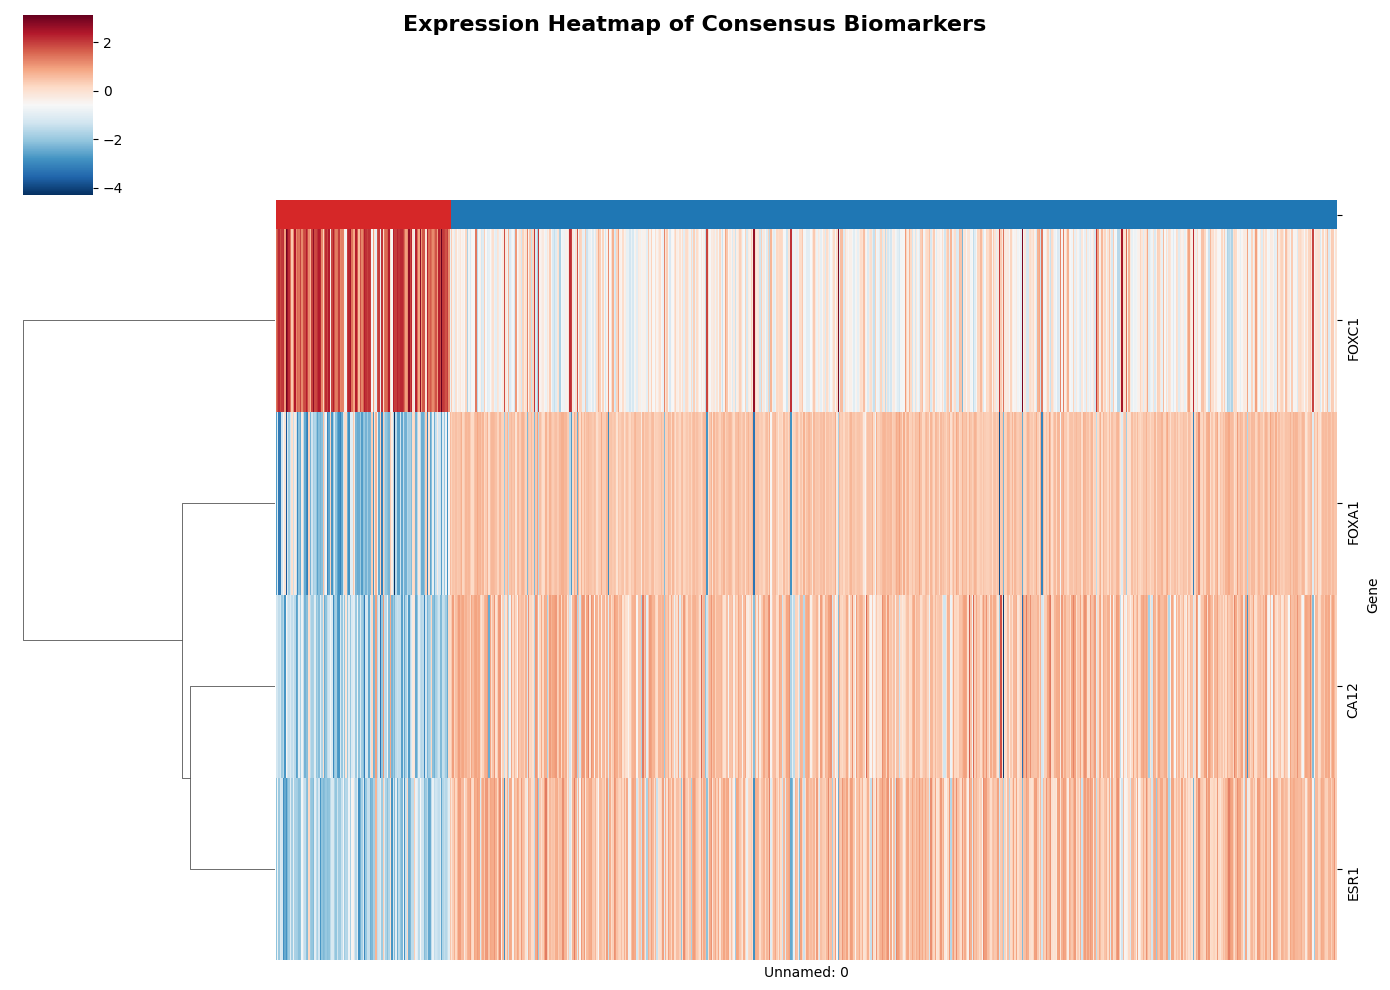

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_annotation = labels.loc[sample_order].map({
    1: "TNBC",
    0: "Non-TNBC"
})

column_colors = sample_annotation.map({
    "TNBC": "#d62728",
    "Non-TNBC": "#1f77b4"
})

g = sns.clustermap(
    heatmap_data,
    cmap="RdBu_r",
    z_score=0,
    row_cluster=True,
    col_cluster=False,      # Keep TNBC and Non-TNBC grouped
    col_colors=column_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14,10)
)

g.fig.suptitle(
    "Expression Heatmap of Consensus Biomarkers",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "Figure6_Consensus_Biomarker_Heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!pip -q install upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from upsetplot import from_contents

gene_sets = {
    "Random Forest": rf_genes,
    "ExtraTrees": et_genes,
    "XGBoost": xgb_genes,
    "CatBoost": cat_genes
}

upset_data = from_contents(gene_sets)

/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

<Figure size 1200x600 with 0 Axes>

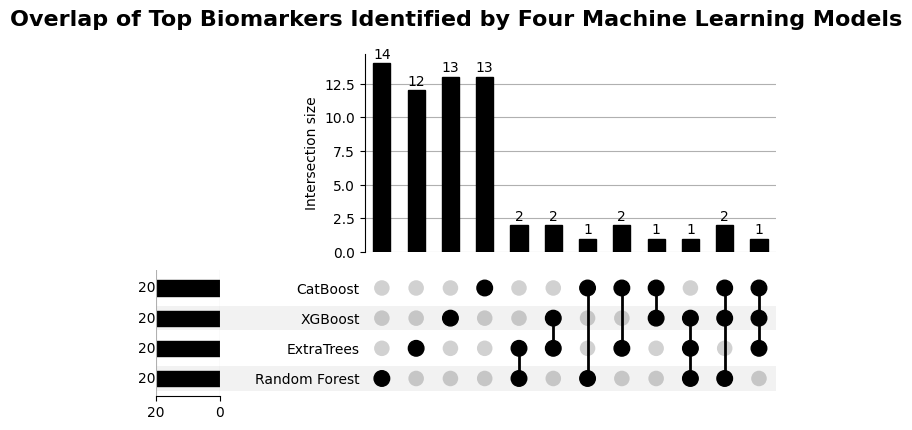

In [ ]:
from upsetplot import UpSet
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

up = UpSet(
    upset_data,
    subset_size='count',
    show_counts=True
)

up.plot()

plt.suptitle(
    "Overlap of Top Biomarkers Identified by Four Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "Figure7_UpSetPlot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# Perform PCA
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X)

In [ ]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Subtype": labels.values
})

pca_df["Subtype"] = pca_df["Subtype"].map({
    1: "TNBC",
    0: "Non-TNBC"
})

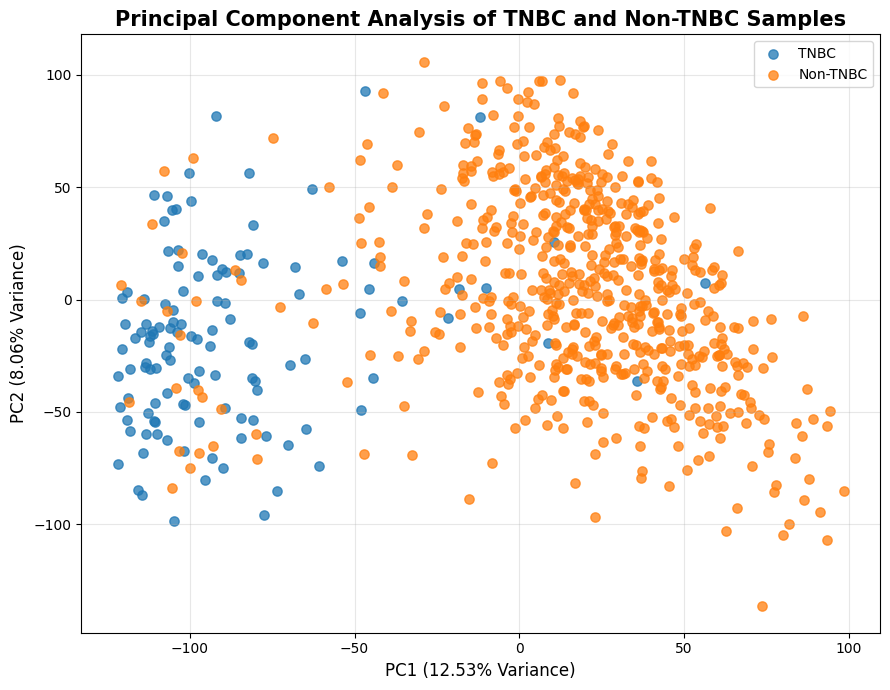

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

for subtype in ["TNBC", "Non-TNBC"]:
    subset = pca_df[pca_df["Subtype"] == subtype]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=subtype,
        alpha=0.75,
        s=45
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)",
    fontsize=12
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)",
    fontsize=12
)

plt.title(
    "Principal Component Analysis of TNBC and Non-TNBC Samples",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure8_PCA_TNBC.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(consensus.head())
print(consensus.columns)

        Random Forest  ExtraTrees  XGBoost  CatBoost  Models Supporting
CA12             True       False     True      True                  3
FOXC1           False        True     True      True                  3
FOXA1            True        True     True     False                  3
ESR1             True       False     True      True                  3
DNALI1           True        True    False     False                  2
Index(['Random Forest', 'ExtraTrees', 'XGBoost', 'CatBoost',
       'Models Supporting'],
      dtype='object')


In [ ]:
print(consensus.head())
print(consensus.columns)

        Random Forest  ExtraTrees  XGBoost  CatBoost  Models Supporting
CA12             True       False     True      True                  3
FOXC1           False        True     True      True                  3
FOXA1            True        True     True     False                  3
ESR1             True       False     True      True                  3
DNALI1           True        True    False     False                  2
Index(['Random Forest', 'ExtraTrees', 'XGBoost', 'CatBoost',
       'Models Supporting'],
      dtype='object')


In [ ]:
consensus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, CA12 to ZNF839
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Random Forest      64 non-null     bool 
 1   ExtraTrees         64 non-null     bool 
 2   XGBoost            64 non-null     bool 
 3   CatBoost           64 non-null     bool 
 4   Models Supporting  64 non-null     int64
dtypes: bool(4), int64(1)
memory usage: 3.3+ KB


In [ ]:
gene_list = consensus.index.tolist()

In [ ]:
print(type(consensus))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
display(consensus.head())

,Random Forest,ExtraTrees,XGBoost,CatBoost,Models Supporting
CA12,True,False,True,True,3
FOXC1,False,True,True,True,3
FOXA1,True,True,True,False,3
ESR1,True,False,True,True,3
DNALI1,True,True,False,False,2


In [ ]:
print(consensus.columns.tolist())

['Random Forest', 'ExtraTrees', 'XGBoost', 'CatBoost', 'Models Supporting']


In [ ]:
print(consensus)

         Random Forest  ExtraTrees  XGBoost  CatBoost  Models Supporting
CA12              True       False     True      True                  3
FOXC1            False        True     True      True                  3
FOXA1             True        True     True     False                  3
ESR1              True       False     True      True                  3
DNALI1            True        True    False     False                  2
...                ...         ...      ...       ...                ...
TTYH1             True       False    False     False                  1
VPS37B           False       False    False      True                  1
XBP1              True       False    False     False                  1
ZMYND10          False        True    False     False                  1
ZNF839           False       False     True     False                  1

[64 rows x 5 columns]


In [ ]:
gene_list = consensus.index.tolist()

print(f"Number of consensus genes: {len(gene_list)}")
print(gene_list[:10])

Number of consensus genes: 64
['CA12', 'FOXC1', 'FOXA1', 'ESR1', 'DNALI1', 'B3GNT5', 'GATA3', 'HAPLN3', 'TBC1D9', 'UGT8']


In [ ]:
high_confidence = consensus[consensus["Models Supporting"] >= 2]

high_confidence_genes = high_confidence.index.tolist()

print(f"High-confidence genes: {len(high_confidence_genes)}")
print(high_confidence_genes)

High-confidence genes: 12
['CA12', 'FOXC1', 'FOXA1', 'ESR1', 'DNALI1', 'B3GNT5', 'GATA3', 'HAPLN3', 'TBC1D9', 'UGT8', 'PRR15', 'WNT6']


In [ ]:
!pip -q install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.6/664.6 kB 9.0 MB/s eta 0:00:00


In [ ]:
import gseapy as gp
import pandas as pd

In [ ]:
organism="hsapiens"

In [ ]:
go_bp = gp.enrichr(
    gene_list=high_confidence_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human",
    outdir="GO_BP_Results",
    cutoff=0.05
)

In [ ]:
go_mf = gp.enrichr(
    gene_list=high_confidence_genes,
    gene_sets="GO_Molecular_Function_2023",
    organism="human",
    outdir="GO_MF_Results",
    cutoff=0.05
)

go_mf.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Molecular_Function_2023,"DNA-binding Transcription Activator Activity, ...",4/348,0.000040,0.001094,0,0,28.552326,289.186137,FOXA1;FOXC1;GATA3;ESR1
1,GO_Molecular_Function_2023,UDP-galactosyltransferase Activity (GO:0035250),2/19,0.000056,0.001094,0,0,234.952941,2299.760158,UGT8;B3GNT5
2,GO_Molecular_Function_2023,Transcription Regulatory Region Nucleic Acid B...,3/224,0.000283,0.003679,0,0,29.814480,243.583582,FOXA1;FOXC1;GATA3
3,GO_Molecular_Function_2023,Sequence-Specific Double-Stranded DNA Binding ...,4/715,0.000637,0.005024,0,0,13.556259,99.750764,FOXA1;FOXC1;GATA3;ESR1
4,GO_Molecular_Function_2023,Sequence-Specific DNA Binding (GO:0043565),4/717,0.000644,0.005024,0,0,13.516830,99.318121,FOXA1;FOXC1;GATA3;ESR1


In [ ]:
go_cc = gp.enrichr(
    gene_list=high_confidence_genes,
    gene_sets="GO_Cellular_Component_2023",
    organism="human",
    outdir=None
)

In [ ]:
print(go_cc.results.shape)
go_cc.results.head()

(20, 10)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Cellular_Component_2023,Perineuronal Net (GO:0072534),1/8,0.004791,0.053881,0,0,259.493506,1385.975083,HAPLN3
1,GO_Cellular_Component_2023,Perisynaptic Extracellular Matrix (GO:0098966),1/9,0.005388,0.053881,0,0,227.045455,1185.987693,HAPLN3
2,GO_Cellular_Component_2023,Euchromatin (GO:0000791),1/44,0.026090,0.107357,0,0,42.167019,153.749833,ESR1
3,GO_Cellular_Component_2023,Heterochromatin (GO:0000792),1/49,0.029015,0.107357,0,0,37.765152,133.686795,FOXC1
4,GO_Cellular_Component_2023,Sperm Flagellum (GO:0036126),1/60,0.035421,0.107357,0,0,30.707242,102.575777,DNALI1


In [ ]:
print(len(high_confidence_genes))
print(high_confidence_genes)

12
['CA12', 'FOXC1', 'FOXA1', 'ESR1', 'DNALI1', 'B3GNT5', 'GATA3', 'HAPLN3', 'TBC1D9', 'UGT8', 'PRR15', 'WNT6']


In [ ]:
libraries = gp.get_library_name(organism="human")

[x for x in libraries if "GO" in x]

['GO_Biological_Process_2021',
 'GO_Biological_Process_2023',
 'GO_Biological_Process_2025',
 'GO_Biological_Process_2026',
 'GO_Cellular_Component_2021',
 'GO_Cellular_Component_2023',
 'GO_Cellular_Component_2025',
 'GO_Cellular_Component_2026',
 'GO_Molecular_Function_2021',
 'GO_Molecular_Function_2023',
 'GO_Molecular_Function_2025',
 'GO_Molecular_Function_2026',
 'SynGO_2022',
 'SynGO_2024']

In [ ]:
print(len(high_confidence_genes))

12


In [ ]:
print(high_confidence_genes)

['CA12', 'FOXC1', 'FOXA1', 'ESR1', 'DNALI1', 'B3GNT5', 'GATA3', 'HAPLN3', 'TBC1D9', 'UGT8', 'PRR15', 'WNT6']


In [ ]:
kegg = gp.enrichr(
    gene_list=high_confidence_genes,
    gene_sets="KEGG_2021_Human",
    organism="human",
    outdir=None,
    cutoff=1.0
)

print(kegg.results.head())
print(kegg.results.shape)

          Gene_set                            Term Overlap   P-value  \
0  KEGG_2021_Human                   Breast cancer   2/147  0.003374   
1  KEGG_2021_Human         Proteoglycans in cancer   2/205  0.006449   
2  KEGG_2021_Human             Nitrogen metabolism    1/17  0.010155   
3  KEGG_2021_Human  Glycosphingolipid biosynthesis    1/45  0.026675   
4  KEGG_2021_Human         Sphingolipid metabolism    1/49  0.029015   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.096737            0                     0   27.369655   
1          0.096737            0                     0   19.492611   
2          0.101551            0                     0  113.477273   
3          0.103029            0                     0   41.206612   
4          0.103029            0                     0   37.765152   

   Combined Score      Genes  
0      155.776523  WNT6;ESR1  
1       98.316951  WNT6;ESR1  
2      520.835341       CA12  
3      149.333257     

In [ ]:
all_consensus_genes = consensus.index.tolist()

print(len(all_consensus_genes))

64


In [ ]:
kegg = gp.enrichr(
    gene_list=all_consensus_genes,
    gene_sets="KEGG_2021_Human",
    organism="human",
    outdir=None,
    cutoff=1.0
)

In [ ]:
print(kegg.results.shape)
kegg.results.head(10)

(78, 10)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Sphingolipid metabolism,2/49,0.010761,0.455828,0,0,13.650652,61.861845,UGT8;DEGS2
1,KEGG_2021_Human,Breast cancer,3/147,0.011688,0.455828,0,0,6.759563,30.074655,WNT6;ERBB2;ESR1
2,KEGG_2021_Human,Pathways in cancer,5/531,0.027386,0.464117,0,0,3.127215,11.250862,AR;WNT6;ERBB2;CKS2;ESR1
3,KEGG_2021_Human,Proteoglycans in cancer,3/205,0.027996,0.464117,0,0,4.804577,17.179629,WNT6;ERBB2;ESR1
4,KEGG_2021_Human,Cardiac muscle contraction,2/87,0.031682,0.464117,0,0,7.533586,26.005973,COX7B;CACNA2D2
5,KEGG_2021_Human,Prostate cancer,2/97,0.038640,0.464117,0,0,6.737182,21.919201,AR;ERBB2
6,KEGG_2021_Human,Nitrogen metabolism,1/17,0.053050,0.464117,0,0,19.761905,58.031299,CA12
7,KEGG_2021_Human,Pathways of neurodegeneration,4/475,0.065587,0.464117,0,0,2.755131,7.506027,WNT6;COX7B;XBP1;DNALI1
8,KEGG_2021_Human,Gastric cancer,2/149,0.082417,0.464117,0,0,4.342550,10.838851,WNT6;ERBB2
9,KEGG_2021_Human,Non-alcoholic fatty liver disease,2/155,0.088149,0.464117,0,0,4.170989,10.130196,COX7B;XBP1


In [ ]:
kegg = gp.enrichr(
    gene_list=all_consensus_genes,
    gene_sets="KEGG_2021_Human",
    organism="human",
    outdir=None,
    cutoff=1.0
)

print(kegg.results.shape)

(78, 10)


In [ ]:
all_consensus_genes = consensus.index.tolist()

print(all_consensus_genes)

['CA12', 'FOXC1', 'FOXA1', 'ESR1', 'DNALI1', 'B3GNT5', 'GATA3', 'HAPLN3', 'TBC1D9', 'UGT8', 'PRR15', 'WNT6', 'C17orf28', 'C1QL2', 'C6orf211', 'AR', 'CD300LG', 'CACNA2D2', 'C8orf46', 'C6orf97', 'C1orf64', 'DEGS2', 'CKS2', 'COX7B', 'ERBB2', 'DZIP1', 'DACH1', 'ABCC8', 'ARSG', 'BBS1', 'BPI', 'AGR2', 'GABRP', 'FSIP1', 'FAM171A1', 'FAM48A', 'ESYT3', 'IFRD1', 'GRB7', 'GPR160', 'LCT', 'LEMD1', 'MYB', 'MICALL1', 'PPP1R14C', 'INPP4B', 'KRT83', 'HPDL', 'RND1', 'RASGEF1C', 'RABEP1', 'ROPN1', 'SOX10', 'SPDEF', 'SDR42E1', 'S100B', 'TMEM217', 'STAC', 'VGLL1', 'TTYH1', 'VPS37B', 'XBP1', 'ZMYND10', 'ZNF839']


In [ ]:
reactome = gp.enrichr(
    gene_list=all_consensus_genes,
    gene_sets="Reactome_2022",
    organism="human",
    outdir=None,
    cutoff=1.0
)

In [ ]:
print(reactome.results.shape)

reactome.results.head(10)


(181, 10)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_2022,GRB7 Events In ERBB2 Signaling R-HSA-1306955,2/5,0.000100,0.017182,0,0,214.333333,1973.703188,GRB7;ERBB2
1,Reactome_2022,Sphingolipid Metabolism R-HSA-428157,4/89,0.000190,0.017182,0,0,15.569412,133.418217,UGT8;ESYT3;ARSG;DEGS2
2,Reactome_2022,Glycosphingolipid Metabolism R-HSA-1660662,3/45,0.000403,0.024307,0,0,23.295082,182.094672,UGT8;ESYT3;ARSG
3,Reactome_2022,Estrogen-dependent Gene Expression R-HSA-9018519,4/119,0.000575,0.026008,0,0,11.490435,85.736512,FOXA1;MYB;GATA3;ESR1
4,Reactome_2022,TFAP2 (AP-2) Family Regulates Transcription Of...,2/13,0.000769,0.027823,0,0,58.431085,419.006821,ERBB2;ESR1
5,Reactome_2022,Sema4D Induced Cell Migration And Growth-Cone ...,2/20,0.001845,0.055669,0,0,35.695341,224.704832,ERBB2;RND1
6,Reactome_2022,Sema4D In Semaphorin Signaling R-HSA-400685,2/24,0.002659,0.068745,0,0,29.199413,173.150648,ERBB2;RND1
7,Reactome_2022,ESR-mediated Signaling R-HSA-8939211,4/188,0.003096,0.070042,0,0,7.156522,41.348328,FOXA1;MYB;GATA3;ESR1
8,Reactome_2022,Nuclear Signaling By ERBB4 R-HSA-1251985,2/32,0.004700,0.094520,0,0,21.404301,114.731668,S100B;ESR1
9,Reactome_2022,Transcriptional Regulation By AP-2 (TFAP2) Fam...,2/36,0.005921,0.107166,0,0,18.882353,96.853031,ERBB2;ESR1


In [ ]:
reactome.results.to_csv(
    "Reactome_Pathway_Results.csv",
    index=False
)

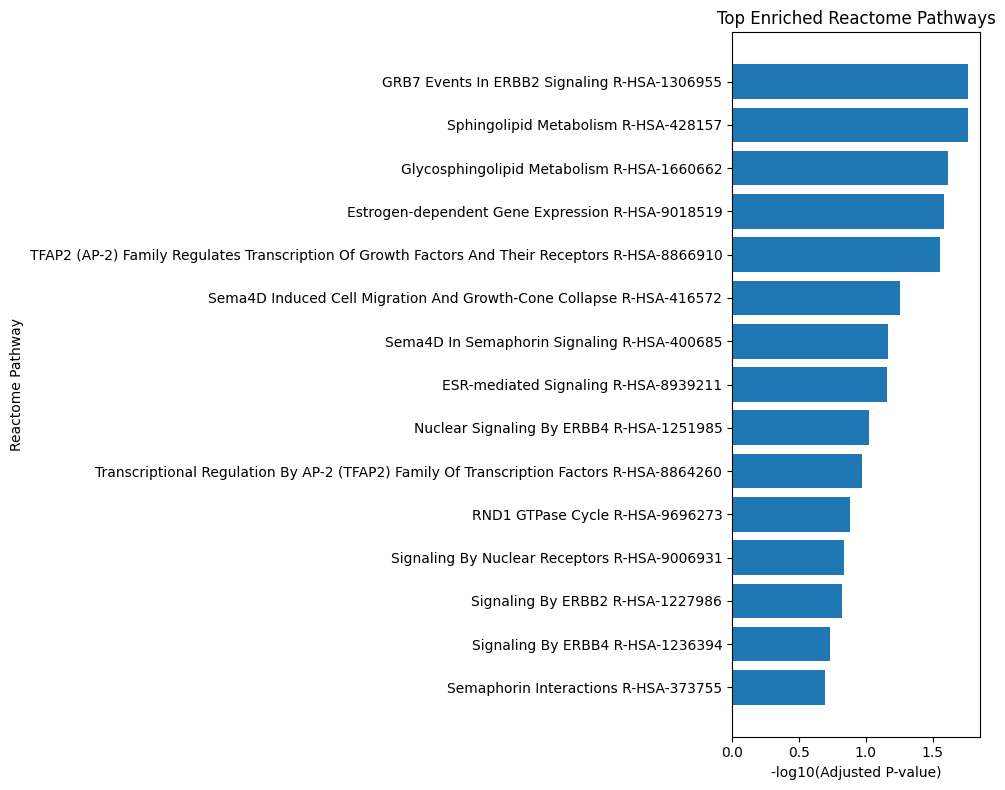

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

top15 = (
    reactome.results
    .sort_values("Adjusted P-value")
    .head(15)
)

plt.figure(figsize=(10,8))

plt.barh(
    top15["Term"],
    -np.log10(top15["Adjusted P-value"])
)

plt.xlabel("-log10(Adjusted P-value)")
plt.ylabel("Reactome Pathway")
plt.title("Top Enriched Reactome Pathways")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "Figure11_Reactome_Pathway_Enrichment.png",
    dpi=600
)

plt.show()

In [ ]:
# Save all important outputs from Notebook 7

consensus.to_csv("Consensus_Biomarkers.csv", index=True)

go_bp.results.to_csv("GO_BP_Results.csv", index=False)

go_mf.results.to_csv("GO_MF_Results.csv", index=False)

try:
    go_cc.results.to_csv("GO_CC_Results.csv", index=False)
except:
    print("No significant GO Cellular Component results.")

kegg.results.to_csv("KEGG_Results.csv", index=False)

reactome.results.to_csv("Reactome_Results.csv", index=False)

print("All Notebook 7 outputs saved successfully!")

All Notebook 7 outputs saved successfully!


In [ ]:
from google.colab import files

files.download("Consensus_Biomarkers.csv")
files.download("GO_BP_Results.csv")
files.download("GO_MF_Results.csv")
files.download("KEGG_Results.csv")
files.download("Reactome_Results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>